# Stage 6 — Modelling
**Goal:** Predict `Accident_Severity` given location & road conditions  
**Model:** Random Forest Classifier (simple, interpretable)  
**Input:** `data/04_processed/accidents_features.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

PROCESSED_DIR = Path('../../data/04_processed')
MODEL_DIR     = Path('../../models/trained')
FIG_DIR       = Path('../../reports/figures')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / 'accidents_features.csv')
print('Shape:', df.shape)
df.head()

Shape: (1207, 12)


,Province_enc,District_enc,Road_Type_enc,Intersection_Type_enc,Time_of_Day_enc,Weather_Condition_enc,Road_Surface_enc,Vehicle_Type_enc,Driver_Gender_enc,Speed_Zone,Year,Severity_Label
0,6,12,1,1,0,0,2,5,1,50,2026,0
1,0,4,0,0,1,0,1,1,0,50,2025,2
2,4,15,3,3,2,0,1,6,1,30,2023,0
3,5,22,3,0,0,0,2,4,1,80,2024,1
4,6,0,3,3,3,0,3,5,1,50,2023,2


## 6.1 Split Features & Target

In [2]:
X = df.drop(columns=['Severity_Label'])
y = df['Severity_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)
print('Class distribution (train):\n', y_train.value_counts().sort_index())

Train size: (965, 11)
Test size : (242, 11)
Class distribution (train):
 Severity_Label
0    206
1    443
2    233
3     83
Name: count, dtype: int64


## 6.2 Train Random Forest

In [3]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 6.3 Predictions

In [9]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.2%}')

label_names = ['Damage Only', 'Minor Injury', 'Serious Injury', 'Fatal']
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=label_names))

Test Accuracy: 44.21%

Classification Report:
                precision    recall  f1-score   support

   Damage Only       0.25      0.13      0.17        52
  Minor Injury       0.49      0.82      0.61       111
Serious Injury       0.33      0.16      0.21        58
         Fatal       0.00      0.00      0.00        21

      accuracy                           0.44       242
     macro avg       0.27      0.28      0.25       242
  weighted avg       0.36      0.44      0.37       242



/Users/aashishbiswocarma_macbookair/FDS_Project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aashishbiswocarma_macbookair/FDS_Project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aashishbiswocarma_macbookair/FDS_Project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

## 6.4 Confusion Matrix

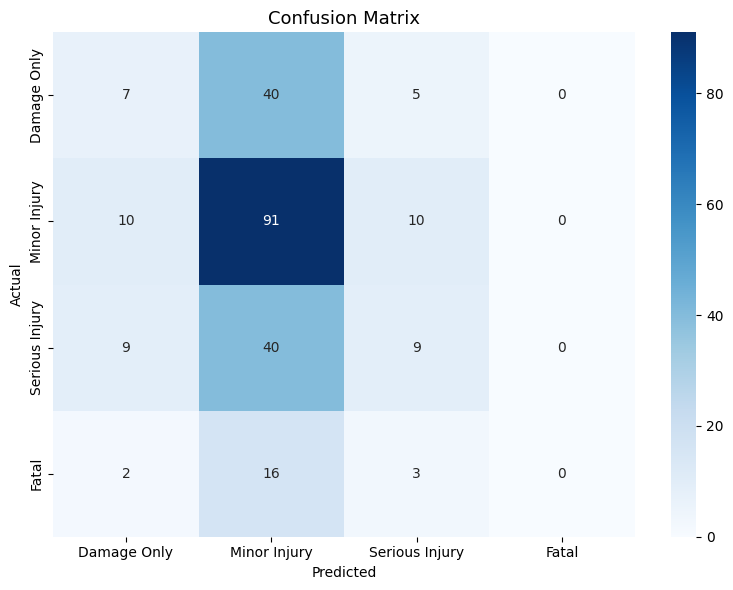

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_title('Confusion Matrix', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
fig.savefig(FIG_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 6.5 Feature Importance

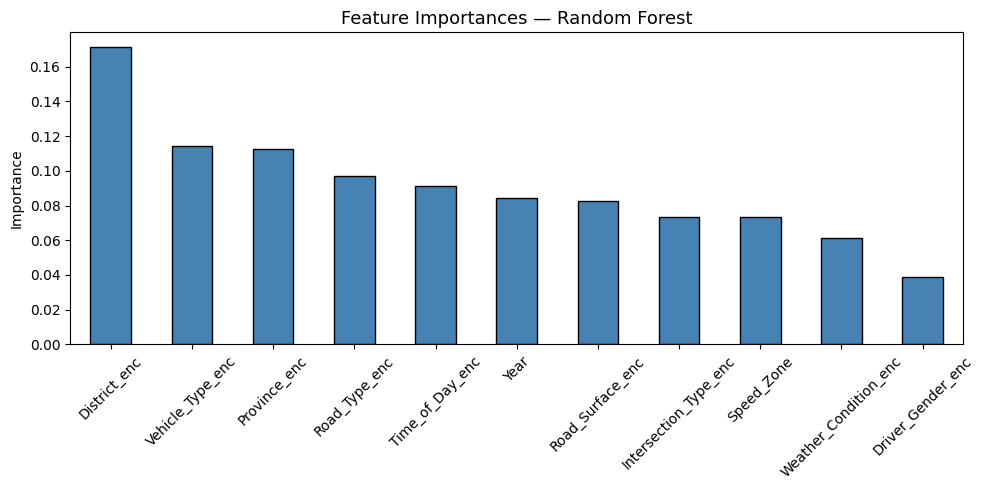

In [6]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Feature Importances — Random Forest', fontsize=13)
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(FIG_DIR / 'feature_importance.png', dpi=150)
plt.show()

## 6.6 Save Model

In [7]:
joblib.dump(clf, MODEL_DIR / 'severity_classifier.pkl')
print('Model saved to:', MODEL_DIR / 'severity_classifier.pkl')

Model saved to: ../../models/trained/severity_classifier.pkl


## 6.7 Driver Warning Demo

Given a driver's location and conditions → predict severity → issue warning.

In [8]:
severity_labels = {0: '🟢 LOW  — Damage Only',
                   1: '🟡 MODERATE — Minor Injury',
                   2: '🟠 HIGH — Serious Injury',
                   3: '🔴 CRITICAL — Fatal'}

# Example: driver in Bagmati, Night, Highway, Slippery, Rain, 80 km/h zone
# (use the same encoded values your label encoder produced)
# For demo we use column medians and swap a few key features
sample = X_test.iloc[[0]].copy()
pred = clf.predict(sample)[0]
prob = clf.predict_proba(sample)[0]

print('=== Driver Warning System ===')
print(f'Predicted Severity Zone : {severity_labels[pred]}')
print(f'Confidence              : {prob[pred]:.0%}')
print(f'Class probabilities     : { {label_names[i]: f"{p:.0%}" for i,p in enumerate(prob)} }')

=== Driver Warning System ===
Predicted Severity Zone : 🟡 MODERATE — Minor Injury
Confidence              : 56%
Class probabilities     : {'Damage Only': '21%', 'Minor Injury': '56%', 'Serious Injury': '17%', 'Fatal': '6%'}
